<a href="https://colab.research.google.com/github/manan36chauhan/GH1047553M504-M505/blob/First-init/GH1047553M505IntroToAIandMachinelearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## M505 Intro to AI and Machine Learning
### Name:- Manan Girishbhai Chauhan
### StudentID : GH1047553

### Problem Statement:-
- This dataset define the core problem and goal of the project an e-commerce company wants to predict if a website visitor will make a purchase based on their browsing behaviour and session.
- As the newly appointed data scientist at e-commerce company the business problem is low conversion rates only 15% of website result in purchases and leading to lost the revenue. this is important because improving prediction of intention can be enable personalized marketing, advertisements and better user experience sales can be increasing by 20-30 %.
- This is a binary classification ML task to predict revenue based on features and solving this benefits the company by optimizing resources and boosting profits.

### Feature Explanation:-
- Administrative: Number of admin pages
- Administrative_Duration: Total time spent on admin pages
- Informational: Number of  informational pages.
- Informational_Duration: Total time spent on informational pages.
- ProductRelated : Product related pages numbers
- ProductRelated_Duration: Total time spent on product related pages longer times consideration.
- BounceRates: Percentage of visitor who leave after viewing single page
- ExitRates : Percentage pf pageview where the page was last in the session.
- PageValues: Average economic value of page visited before purchase
- Specialday: Numeric indicatrtor of special days
- Feature: Description or possible value
- Month: Month of session
- Operating systems: Operating system of user
-Region : Geographic region of the vistiors.
- TrafficType: How the visitor arrived
- VisitorType: Type of visitor returnig,newm other.
- Weekend: True if session on weekend
- Revenue: Target feature binary label true or false.


### Step 1:-
- Importing libraries, models, and accuracy libraries.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV,train_test_split
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier,RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (roc_auc_score,confusion_matrix,accuracy_score,precision_score,
                           recall_score,f1_score,roc_curve,classification_report,average_precision_score)
import joblib
import warnings
warnings.filterwarnings('ignore')

### Step 2:- Data Collection and Loading
#### Data Source
- https://www.kaggle.com/datasets/imakash3011/online-shoppers-purchasing-intention-dataset?resource=download
- the dataset is loaded and shows that we have 12330 rows and 18 coulumns. this step ensures the dataset is accesible.

In [ ]:
df = pd.read_csv('online_shoppers_intention.csv')
print(f"Dataset loaded successfully.....")
print(f"Shape of dataset in rows and colums--->: {df.shape}")

Dataset loaded successfully.....
Shape of dataset in rows and colums--->: (12330, 18)


### Step 3:- Data Exploration and Understanding overall
- We are examining the datasets structure like info rows columns and datatypes. value counts of the target variable displayed. in this step we are also having first 5 rows of datasets by using head().

In [ ]:
print("rows of dataset:" ,df.shape[0])
print("columns of dataset:",df.shape[1])
print(df.dtypes)
print("\nWhat we want to predict:")
print(f"Revenue column: {df['Revenue'].dtype}")
print("Revenue distribution using value_counts:-")
print(df['Revenue'].value_counts())
df.head()


rows of dataset: 12330
columns of dataset: 18
Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                 object
Weekend                       bool
Revenue                       bool
dtype: object

What we want to predict:
Revenue column: bool
Revenue distribution using value_counts:-
Revenue
False    10422
True      1908
Name: count, dtype: int64


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


### Step 4: Cleaning and Preprocessing of the dataset for better predictions
- checking missing values if yes then removing
- checking for duplicated values if yes then removing
- class based analysis can be shown in this step false 10297 distribution and true are 1908 it indicates imbalance.
- Count plot analyze the distribution of the target feature- Revenue.
- This shows we can clean the dataset and imbalance dataset can be handled during model training.



Series([], dtype: int64)
Boom No missing values found
Removed duplicate in 125 rows
shape of New dataset: (12205, 18)
  False: 10297 samples (84.4%)
  True: 1908 samples (15.6%)


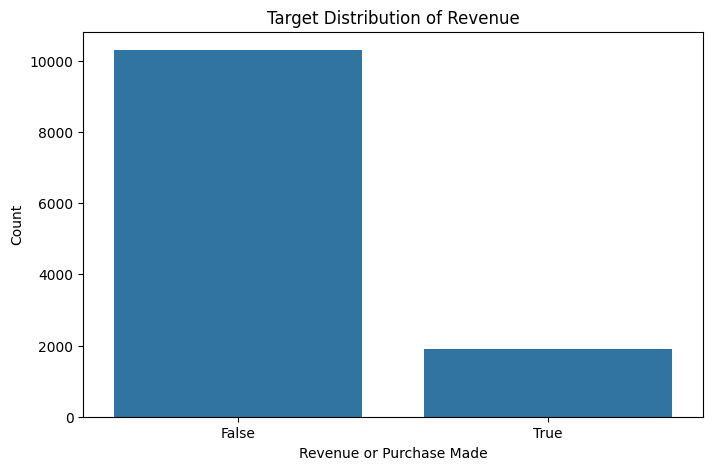

In [ ]:
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])
if missing_values.sum() == 0:
    print("Boom We dont have missing values")

# Check for duplicated
duplicates = df.duplicated().sum()
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"Removed duplicate in {duplicates} rows")
    print(f"shape of New dataset: {df.shape}")

# Check class balance for overfitting or data leakage
class_counts = df['Revenue'].value_counts()
class_percentages = df['Revenue'].value_counts(normalize=True) * 100
for value, count, pct in zip(class_counts.index, class_counts.values, class_percentages.values):
    print(f"  {value}: {count} samples ({pct:.1f}%)")

# Visualize class distribution for target
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Revenue')
plt.title('Target Distribution of Revenue')
plt.xlabel('Revenue or Purchase Made')
plt.ylabel('Count')
plt.show()


### Step 5: Feature Engineering
- we will create a new feature combining three features from the dataset.
- We wil convert boolean to numeric in this weekend and revenure are converted to interger and new feature is created total_pages and it is sum of Administrative, informational and product related and the total duration is avg_time_per_page and total_pages + 1.

In [ ]:
df['Weekend'] = df['Weekend'].astype(int)
df['Revenue'] = df['Revenue'].astype(int)


# create features for better prediction
df['Total_Pages'] = df['Administrative'] + df['Informational'] + df['ProductRelated']
df['Total_Duration'] = (df['Administrative_Duration'] +
                       df['Informational_Duration'] +
                       df['ProductRelated_Duration'])

# average time per page or visits per page
df['Avg_Time_Per_Page'] = df['Total_Duration'] / (df['Total_Pages'] + 1)

### Step 6: Train Test and Split
- In this step we are separating target 'Revenue'. data is split using train_test_split like 80% training and 20 % test with stratification to maintain class proportion and random_state 42 for reproducibility. it prepares data for model training and evaluation and also ensures unbiased testing.

In [ ]:
# Separate features and target for accuracy
X = df.drop('Revenue', axis=1)
y = df['Revenue']

print(f"Features and target shape: {X.shape}")


# Spliting the dataset in 80% for training and 20% for testing with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Data spliting completed:")
print(f"Training set: {X_train.shape[0]}")
print(f"Testing set: {X_test.shape[0]}")

Features and target shape: (12205, 20)
Data split completed:
Training set: 9764
Test set: 2441


### Step 7 : Correalation Analysis
- 18 Numeric columns are selected for correlation matrix visulaized as a heatmap with annotatons. Features most correlated with revenue are listed pagevalues 0.49 Exitrate 0.204 this identifies influential features and guides to reveal the relationship like high pagevalues strongly linking to purchase.


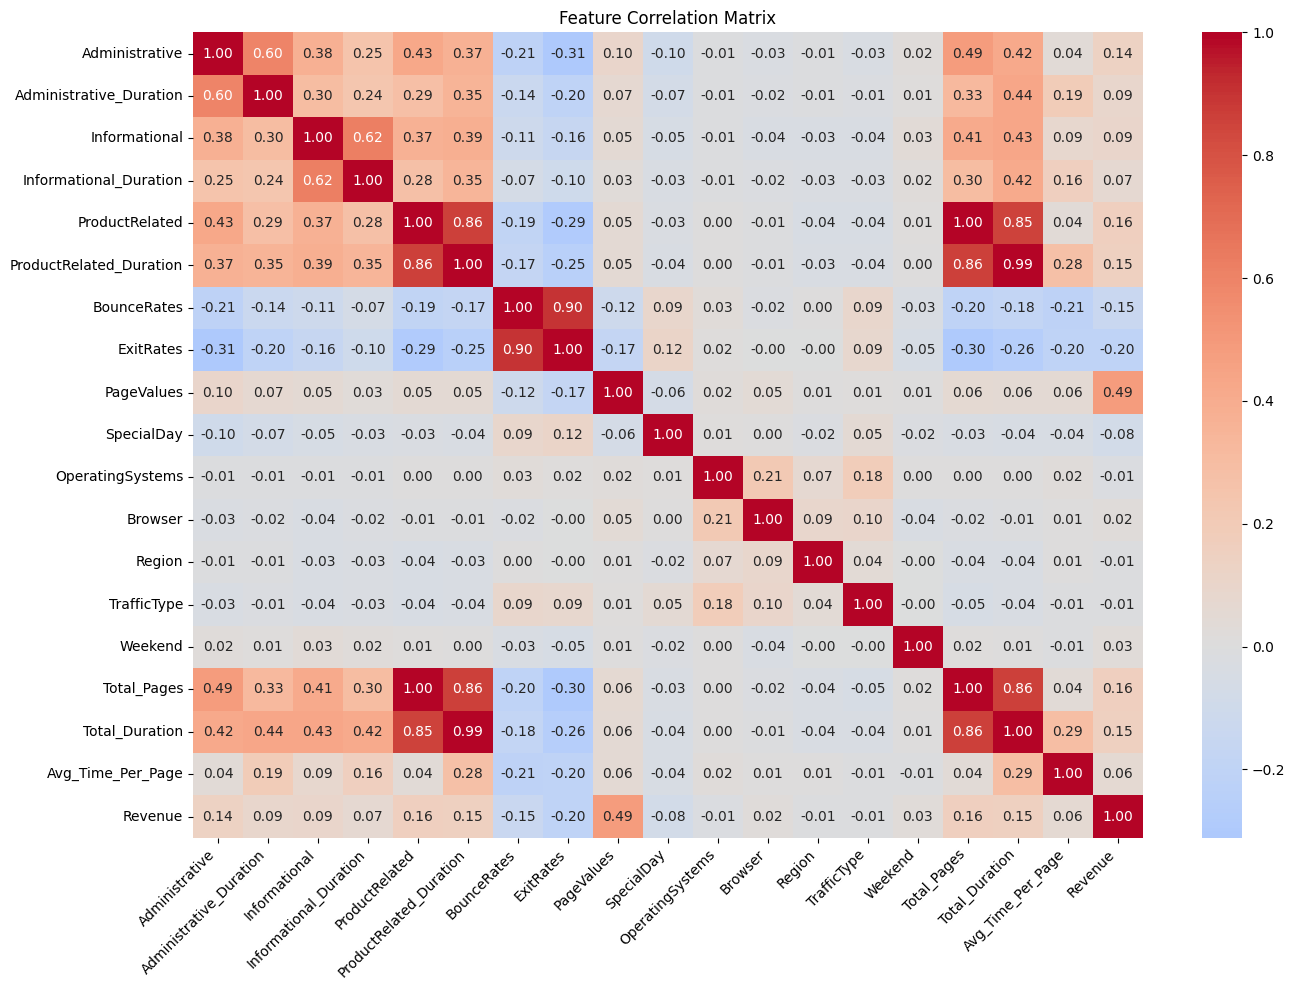


 Features mostly correlated with target:
   PageValues: 0.492
   ExitRates: 0.204
   Total_Pages: 0.162
   ProductRelated: 0.156
   Total_Duration: 0.154
   ProductRelated_Duration: 0.150
   BounceRates: 0.145
   Administrative: 0.136
   Informational: 0.094


In [ ]:
# Select only numeric columns for correlation
numeric_columns = X.select_dtypes(include=[np.number]).columns.tolist()
correlation_matrix = df[numeric_columns + ['Revenue']].corr()
# Plot correlation heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix,
            annot=True,
            cmap='coolwarm',
            center=0,
            fmt='.2f')
plt.title('Correlation Matrix for all Features')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

target_correlation = correlation_matrix['Revenue'].abs().sort_values(ascending=False)
print("\n Features mostly correlated with target:")
for feature, corr in target_correlation.head(10).items():
    if feature != 'Revenue':
        print(f"   {feature}: {corr:.3f}")

### Step 8 :Data Preprocessing for models
- As we have seen above our dataset is imbalannce and we will try to preprocess for the mdoels like naive bayes and gredientboost.
- Numeric features like  Administrative and categorical features are defined. we are using column transfer to create standardscalar for numerics and OnehoteEncoder for categories. it handles and prepare for model input.


In [ ]:
numeric_features = ['Administrative', 'Administrative_Duration', 'Informational',
                   'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
                   'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay',
                   'Total_Pages', 'Total_Duration', 'Avg_Time_Per_Page']

categorical_features = ['Month', 'OperatingSystems', 'Browser', 'Region',
                       'TrafficType', 'VisitorType', 'Weekend']

print(f" How many numerical features listed : {len(numeric_features)}")
print(f"how many categorical features listed: {len(categorical_features)}")

# pipeline creation for standardscaler using transformer
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
])



Numeric features numbers: 13
Categorical features numbers: 7


### Step 9: Models Building and Training
- in this step after preprocessing wr are training six models logistic, decision,Random forest, Support Vector, Naive Bayes, Gradient Boosting with balanced class weight and random state with 42. predfiction and probabilities are made on test data.
-Naive Bayes handles sparse data by converting arrays

In [ ]:
models = {
    'Logistic Regression': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000))
    ]),

    'Decision Tree': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier(class_weight='balanced', random_state=42))
    ]),

    'Random Forest': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=100))
    ]),

    'Gradient Boosting': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', GradientBoostingClassifier(random_state=42))
    ]),

    'Support Vector Machine': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', SVC(class_weight='balanced', random_state=42, probability=True))
    ]),

    'Naive Bayes': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', GaussianNB())
    ])
}

results = {}
trained_models = {}

for name, model in models.items():
    if name == 'Naive Bayes':
        X_train_processed = preprocessor.fit_transform(X_train).toarray()
        X_test_processed = preprocessor.transform(X_test).toarray()
        model.named_steps['classifier'].fit(X_train_processed, y_train)
        trained_models[name] = model
        y_pred = model.named_steps['classifier'].predict(X_test_processed)
        y_prob = model.named_steps['classifier'].predict_proba(X_test_processed)[:, 1]
    else:

        model.fit(X_train, y_train)
        trained_models[name] = model


        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    }
print('All Model Trained Perfectly.....')

All Model Trained.....


### Step 10:Model Evaluation and Comparison
- Comparison of performances of all trained models was used to check accuracy, F1-score, and ROC-AUC. we can see that the Gradient Boosting performed well out to be the best performing method with about 90% accurate results and it is giving a balanced F1-score.

                        Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression       0.8468     0.5067  0.7958    0.6191   0.9095
Decision Tree             0.8636     0.5646  0.5602    0.5624   0.7400
Random Forest             0.9000     0.7518  0.5393    0.6280   0.9181
Gradient Boosting         0.9033     0.7186  0.6283    0.6704   0.9363
Support Vector Machine    0.8718     0.5665  0.7696    0.6526   0.9082
Naive Bayes               0.2778     0.1757  0.9791    0.2979   0.7641

Best model using metric--->:
Accuracy: Gradient Boosting (0.9033)
Precision: Random Forest (0.7518)
Recall: Naive Bayes (0.9791)
F1-Score: Gradient Boosting (0.6704)
ROC-AUC: Gradient Boosting (0.9363)


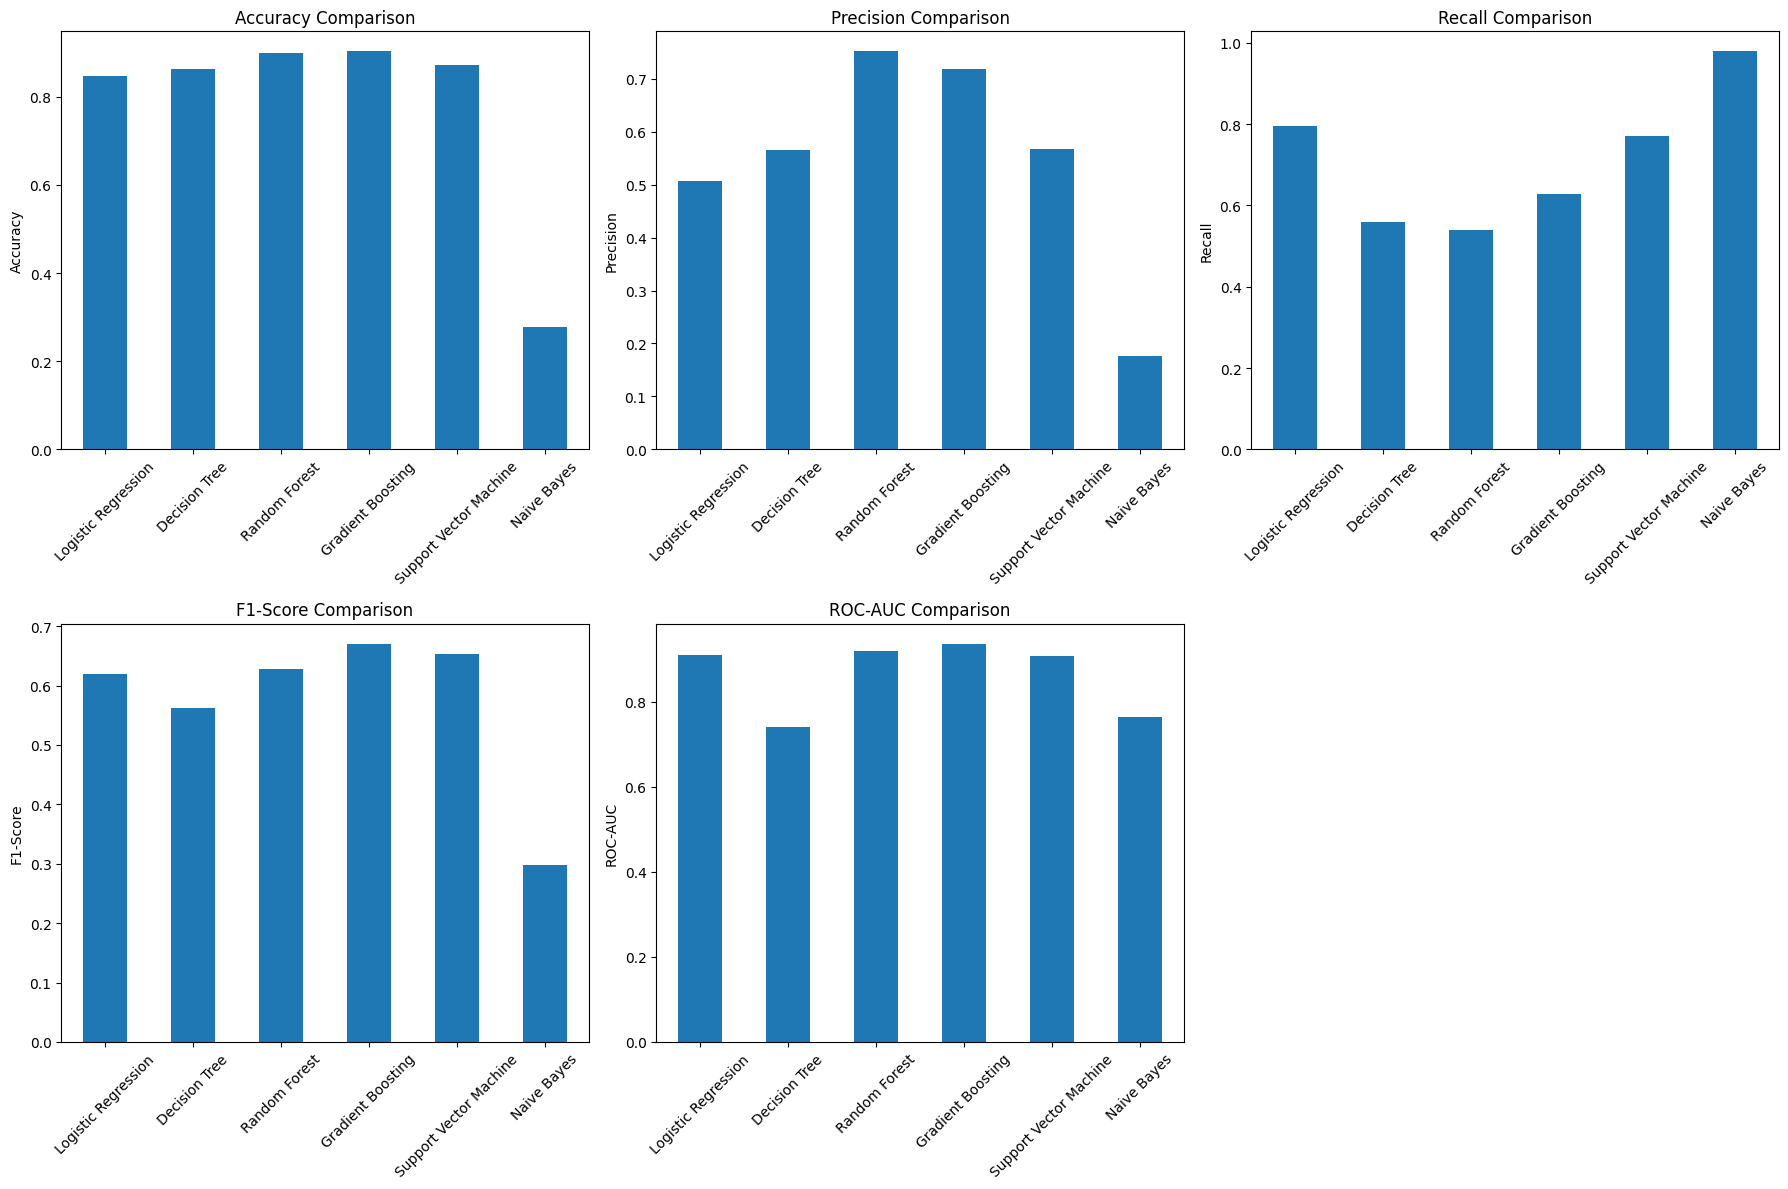

In [ ]:
results_df = pd.DataFrame(results).T
results_df = results_df.round(4)
print(results_df)
print(f"\nBest model using metric--->:")
for metric in results_df.columns:
    best_model = results_df[metric].idxmax()
    best_score = results_df[metric].max()
    print(f"{metric}: {best_model} ({best_score:.4f})")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

for i, metric in enumerate(metrics):
    row = i // 3
    col = i % 3

    results_df[metric].plot(kind='bar', ax=axes[row, col])
    axes[row, col].set_title(f'{metric} Comparison')
    axes[row, col].set_ylabel(metric)
    axes[row, col].tick_params(axis='x', rotation=45)

fig.delaxes(axes[1, 2])
plt.tight_layout()
plt.show()

### Step 11 : Analysis of model
- Best model Gradient Boosting, F1-Score: 0.6704 is selected. We are using confusion matrix to see a different view

- The Gradient Boosting model reached the highest accuracy rate at 90% which made it the most effective solution.
- The model achieved excellent results for the majority class (0) by reaching precision at 0.93 and recall at 0.95.
- The F1-score for class 0 reached 0.94 which indicates the model achieved balanced performance.
- The model achieved acceptable results for the minority class ( because its recall score reached 0.63 the F1-score for class 1 reached 1) with precision at 0.72.
- The model showed limited ability to detect all positive cases0.67 which demonstrates a fair balance between precision and recall performance.
- The analysis used a confusion matrix together with the classification report to provide additional understanding



Detailed Classification for best model:-  Gradient Boosting:
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      2059
           1       0.72      0.63      0.67       382

    accuracy                           0.90      2441
   macro avg       0.83      0.79      0.81      2441
weighted avg       0.90      0.90      0.90      2441



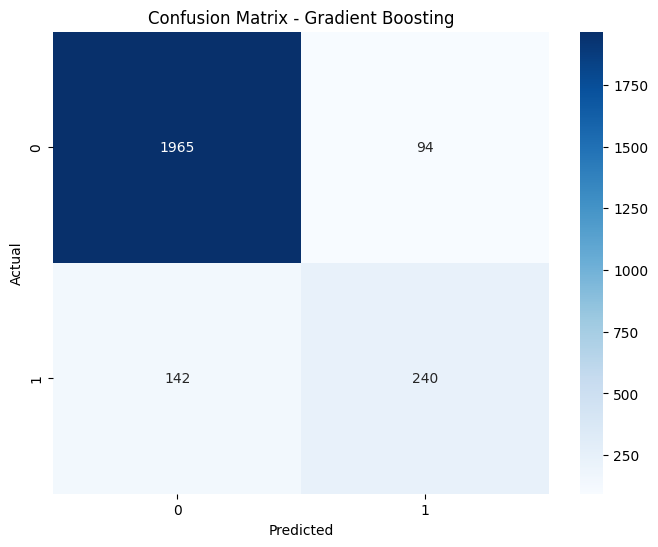

In [ ]:
best_model_name = results_df['F1-Score'].idxmax()
best_model = trained_models[best_model_name]
best_f1_score = results_df.loc[best_model_name, 'F1-Score']


y_pred_best = best_model.predict(X_test)
y_prob_best = best_model.predict_proba(X_test)[:, 1]
print(f"\nDetailed Classification for best model:-  {best_model_name}:")
print(classification_report(y_test, y_pred_best))

# Confusion Matrix for predicted and actual
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Step 12 : Interpretation of models or checking ROC
- This translates results to business value, like reducing false positives in marketing.
- Metrics are explained: overall correctness,positive prediction accuracy,catching positives,balance for imbalance, ROC-AUC class separation.

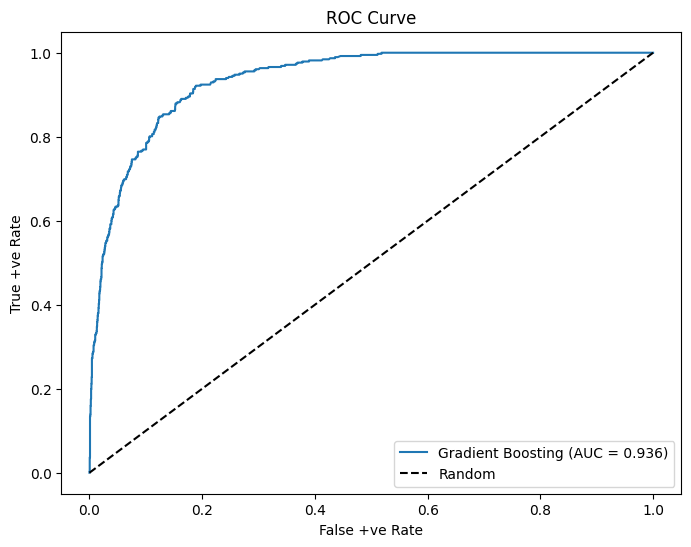

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_prob_best)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'{best_model_name} (AUC = {roc_auc_score(y_test, y_prob_best):.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False +ve Rate')
plt.ylabel('True +ve Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


### Final Disucssion:-
- The project delivers a robust pipeline for purchase prediction and it enables marketing and site optimization for customers . in this project we are comparing best models and it is `Gradient Boosting` because it handles non linear and imbalance. For more scalability we made a feature using other features and preprocessed in while tuning and monitoring prepare the model for production.

#### Strenghts:-
- For Comprehensive pipeline: It covers all ML Steps with comparing all trained models like its accuracy and precision.
- We have compared six models to predict the revenue and optimization of website.
- We have done feature engineering for total_pages and Total_duration and it enhance the prediction.

#### Implications:-
- We observed that the buys is 72 out of 100 and boosting conversions and reducing ad waste.
- we can predict real-time predictions for dynamic offerd or data.
- Methodology applies to recomemedations

####  Limitations:-
- Data Imbalance 37 percent of buyers missed and recall 62.8 %.
- Satatic data lacks with temporal or external factors
- Features Moderate correlation and it maximum is 0.492 no advanced features.
- We can see tree models may sometime overfit and has weak validaiton.